# Practice Worksheet 4: Reinforcement Learning

This notebook is part of a larger effort to offer an approachable introduction to models of the mind and the brain, developed by by [Jelle (aka Willem) Zuidema](https://staff.fnwi.uva.nl/w.zuidema/). The notebook in this present form is the result of the combined work of Iris Proff, [Marianne de Heer Kloots](http://mdhk.net/), and [Simone Astarita](https://www.linkedin.com/in/simone-astarita-4499b11b5/).

#### Introduction
This lab will guide you through a reinforcement learning simulation. We will simulate an agent navigating through the maze depicted below. The red dot is the initial position of the agent, $s_1$. The green boxes are terminal states. The stars indicate rewards. 

Each position in the maze is one possible state, thus there are 16 states, which we will index line by line, such that the upper left corner is state 0 and the lower right corner is state 15. Hence, state 1 and state 11 are terminal states. There are four possible action directions, left (0), up (1), right (2) and down (3). Performing an action from a state is only possible if there is no border in the way.

We assume that the setup of the maze is unknown to the agent. We will implement a simple Q-learning algorithm to model how the agent learns which path to take in the maze. 

![title](https://raw.githubusercontent.com/clclab/FNCM/main/book/Lab5-maze.jpg)

### Updating the Q-values

As the agent navigates through the maze, it builds up an estimation of the utility of each state-action pair. This estimation is represented in a 16x4 matrix Q. Each time the agent takes a step, the Q-value of the corresponding state-action pair is updated. Specifically, when moving from state $s$ to state $s'$ with action $a$ and obtaining reward $R$, $Q(s,a)$ is updated according to:

\begin{align*}
    Q_{t+1}(s,a)=Q_t(s,a)+\alpha*\delta
\end{align*}

where $\delta$ is the prediction error, defined by:

\begin{align*}
   \delta = R + \gamma * max_{a'}(Q(s',a'))-Q(s,a)
\end{align*}

Here, $\alpha$ is the learning rate and $\gamma$ is the temporal discount factor. $max_{a'}(Q(s',a'))$ refers to the highest Q-value of state $s'$. $Q(s,a)$ is updated proportionally to the size of the prediction error - the greater the prediction error, the more the agent learns.

<br>

>Complete the function that updates the Q values in the cell below. 

<br>

Hint: use the function np.nanmax() to find the maximum of an array while ignoring nan entries (this will be important when we use the function later on).

In [1]:
def update_Q(a,s,s1,R,Q, gamma, alpha):
    """
    Function to update Q values.
    
    Input:
      a -- action (integer between 0 and 3)
      s -- state (integer between 0 and 15)
      s1 -- new state (integer between 0 and 15)
      R -- reward value
      Q -- (16, 4) array with Q-values for each (s, a) pair
      gamma -- temporal discount value
      alpha -- learning rate
      
    Output:
      Q[s, a] -- updated Q value
      pred_error -- prediction error (delta)
    """
    
    ### YOUR CODE HERE
    
    # compute prediction error
    
    #pred_error = ...
    # update Q value
    #Q[s,a] = ...
    
    ###
    
    ### SOLUTION
    # compute prediction error
    pred_error = R + gamma * np.nanmax(Q[s1,:]) - Q[s,a]
    # update Q value
    Q[s,a] = Q[s,a] + alpha * pred_error
    ###
    
    return Q[s,a], pred_error


### Softmax action selection

The second component of our Q-learning algorithm is an action selection function, that receives the Q-values of the current state as an input and returns an action to be taken. We will implement a softmax action selection function, that assigns probabilities to each action $a_i$ of a given state $s$, depending on its Q-value $q_i$:

\begin{align*}
    P(a_i|s) = \frac{e^{\frac{q_i}{\tau}}}{\sum_A{e^{\frac{q_i}{\tau}}}}
\end{align*}

Here, $\tau > 0$ is the so called temperature parameter. If $\tau$ is close to $0$, the algorithm most likely selects the action with the highest Q-value (i.e. it makes a *greedy* choice). For $\tau \rightarrow \infty$, the algorithm *randomly* selects one of the actions, irrespective of their Q-value. The softmax function is implemented in the cell below.

In [2]:
def softmax_act_select(Q, tau):
    """
    Softmax function for action selection.
    
    Input:
      Q -- (16, 4) array with Q-values for each (s, a) pair
      tau -- temperature parameter
    """
    
    Qs = Q[~np.isnan(Q)] # get valid actions
    actions =np.where(~np.isnan(Q)) # get valid action indices
    actions = actions[0]
    
    # compute probabliities for each action
    x = np.zeros(Qs.size); p = np.zeros(Qs.size);

    for i in range(Qs.size):
        x[i] = np.exp(Qs[i]/tau)/sum(np.exp(Qs)/tau)

    p = x/sum(x)
    
    # choose action
    a = np.random.choice(actions, p = p)
    
    return a

### Running the simulation

Now we are ready to run the simulation. The code below sets values for our model parameter and implements the maze structure. Then it runs the simulation. Our agent has to solve the maze 100 times (you can change this number). In each trial, it starts in the initial state and can move freely around in the maze until it reaches one of the terminal states. 

We store the number of steps the agent takes in each trial, the Q-values after each trial, the prediction errors and visited state of each step and which terminal state was reached in each trial. These results are plotted in the lower cell.

/var/folders/z3/5phhv0hs0gv99cq97_dgrpdc0000gn/T/ipykernel_47598/158532635.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Q[s,a] = Q[s,a] + alpha * pred_error


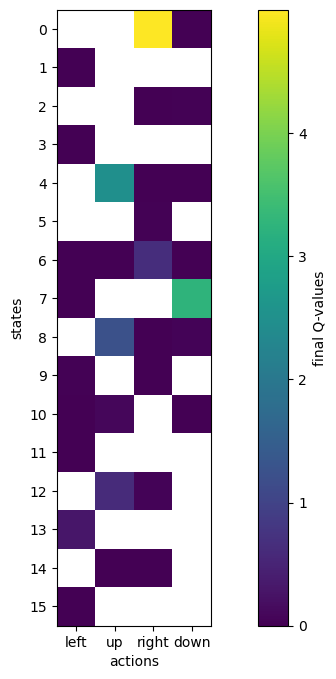

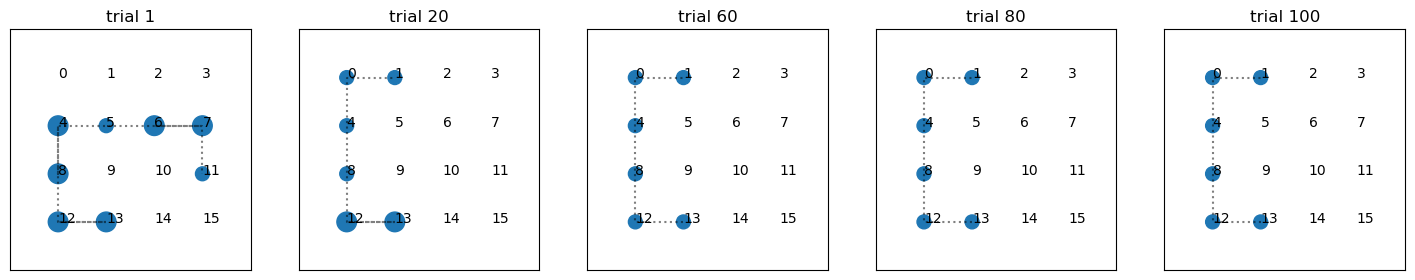

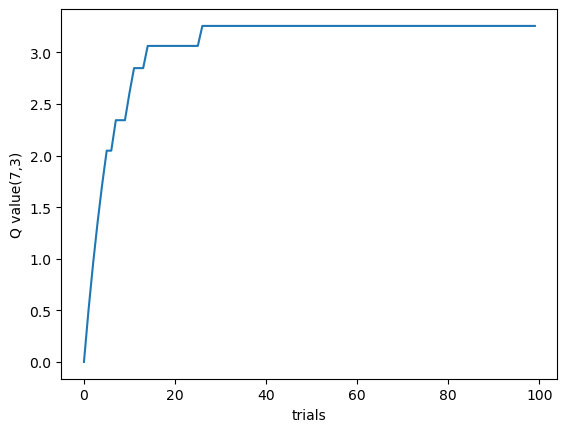

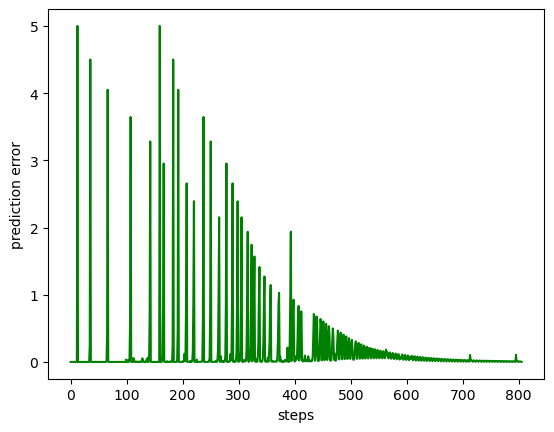

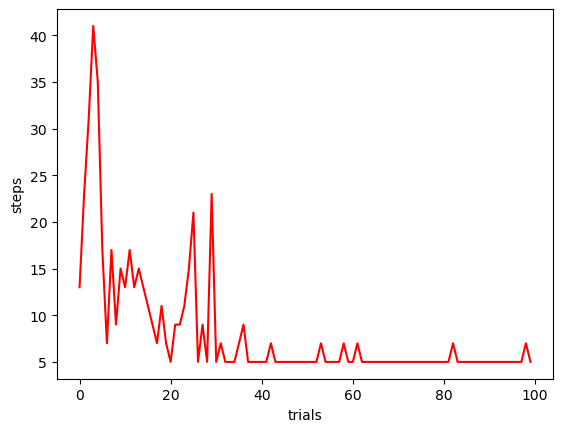

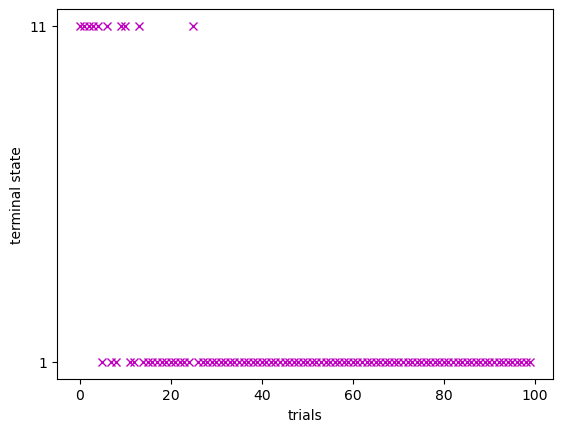

In [6]:
import numpy as np
import matplotlib.pyplot as plt

### set parameter values

alpha = 0.1   # learning rate, 0 < alpha < 1
gamma = 0.5   # temporal discount factor, 0 <= gamma <=1
tau = 0.2     # temperature of softmax action selection, tau > 0
trials = 100  # number of times the agent has to solve the maze

### implement maze structure

# initialize Q(s,a)
Q = np.zeros ([16,4])
Q.fill(np.nan)  # array of nans

# zeros for each possible action
Q[0,2] = 0; Q[0,3] = 0; Q[1,0] = 0; Q[2,2] = 0; Q[2,3] = 0; Q[3,0] = 0
Q[4,1] = 0; Q[4,3] = 0; Q[4,2] = 0; Q[5,2] = 0; Q[6,0] = 0; Q[6,1] = 0; Q[6,2] = 0; Q[6,3] = 0; Q[7,0] = 0; Q[7,3] = 0
Q[8,1] = 0; Q[8,2] = 0; Q[8,3] = 0; Q[9,0] = 0; Q[9,2] = 0; Q[10,0] = 0; Q[10,1] = 0; Q[10,3]= 0; Q[11,0]=0
Q[12,1] = 0; Q[12,2] = 0; Q[13,0] = 0; Q[14,1] = 0; Q[14,2] = 0; Q[15,0] = 0

# terminal and initial states
s_term = [1,11]
s_init = 13

# rewards
Rs = np.zeros ([16,1])
Rs[1] = 5; Rs[11] = 5

### initialize variables to store data 
steps = np.zeros([trials,1])
s_term_meta = np.zeros([trials,1])
Q_meta = np.zeros([trials,16,4])
pred_error_meta = [];
visited_states = []

states = np.arange(16).reshape(4,4)

### run simulation

for trial in range(trials):
    
    # place agent in initial state
    s = s_init
    
    # store initial state
    visited_states.append([s_init])
    
    # store Q values
    Q_meta[trial,:,:] = Q
    
    # continue until in terminal state
    while not(s in s_term):
        # print(s)
        # choose action
        a = softmax_act_select(Q[s], tau)

        # observe new state
        # left
        if a == 0:
            s1 = s-1
        # up
        elif a == 1:
            s1= s-4
        # right
        elif a == 2:
            s1 = s+1
        # down
        else:
            s1 = s+4

        # observe R
        R = Rs[s1]

        # update Q
        Q[s,a], pred_error = update_Q(a,s,s1,R,Q, gamma, alpha)

        # update state
        s = s1
    
        # count steps
        steps[trial] += 1
        
        # store prediction error 
        pred_error_meta.append(pred_error)
        
        # store visited state
        visited_states[trial].append(s1)
    
    # store terminal state
    s_term_meta[trial] = s1
        

### plot some results

# plot final Q-values for each state
plt.figure(figsize=(12,8))
plt.imshow(Q)
cbar = plt.colorbar()
cbar.set_label('final Q-values')
plt.xticks([0,1,2,3], ['left', 'up', 'right', 'down'])
plt.yticks(range(16))
plt.xlabel('actions')
plt.ylabel('states')
plt.show()


###### helper funtions######

# function to get coordinates for given state (used for plotting)
def xy(s):
    x = np.where(states == s)[1][0]
    y = states.shape[0] - 1 - np.where(states == s)[0][0]
    return (x, y)

# function to plot visited states
def plot_map(visited_states):
    visited_path = np.array([xy(st) for st in visited_states])
    visited_unique = np.unique(visited_states)
    visited_xy = np.array([xy(st) for st in visited_unique])
    visited_counts = np.array([visited_states.count(st) for st in visited_unique])
    plt.scatter(visited_xy[:,0], visited_xy[:,1], s=visited_counts*100)
    plt.plot(visited_path[:,0], visited_path[:,1], 'k:', alpha=0.5)
    plt.xlim(-1,4); plt.ylim(-1,4); plt.xticks([]); plt.yticks([])
    for st in states.flatten():
        plt.annotate(st, xy(st))
        
##############################

# plot visited states
plot_trials = [0, 19, 59, 79, 99]
fig = plt.figure(figsize=(18,10))
for i in range(len(plot_trials)):
    ax = fig.add_subplot(1, len(plot_trials), i+1)
    plot_map(visited_states[plot_trials[i]])
    ax.set_title('trial ' + str(plot_trials[i]+1))
    ax.set_aspect(1)
plt.show()

# plot Qvalues over trials
fig, axes = plt.subplots()
s = 7; a = 3 # here you can choose which Q value to plot
plt.plot(Q_meta[:,s,a])
plt.xlabel('trials')
plt.ylabel('Q value({},{})'.format(s,a))
plt.show()

# plot prediction errors
fig, axes = plt.subplots()
plt.plot(pred_error_meta,'g')
plt.xlabel('steps')
plt.ylabel('prediction error')
plt.show()

# plot steps
fig, axes = plt.subplots()
plt.plot(steps,'r')
plt.xlabel('trials')
plt.ylabel('steps')
plt.show()

# plot terminal states
fig, axes = plt.subplots()
plt.plot(s_term_meta,'mx')
plt.xlabel('trials')
plt.ylabel('terminal state')
plt.yticks(s_term)
plt.show()

<br>

> ***Homework exercise 1:*** Describe and explain the evolution of (1) Q-values, (2) prediction errors and (3) step number over time with the given parameter values.
>
> Hint: You can select which Q-value to plot in the code! What does it depend on which final value the Q-values converge to? What is the highest possible Q-value?

> ***Homework exercise 2:*** Play around with the parameter values of the model ($\alpha$, $\gamma$, $\tau$). Describe and explain the effect of each parameter on the behavior of the agent.
    
> ***Homework exercise 3:*** With the original parameter values ($\alpha = 0.1, \gamma = 0.5, \tau = 0.2$), does the agent reach one of the terminal states more often than the other? If so, why is that? How is this affected by the value of the parameters?

> ***Homework exercise 4:*** In how far does the behavior of our Q-learning agent differ from what you would expect from a human agent solving the same task (assuming that she does not know the strucutre of the maze, location of terminal states and size of rewards)? Can you think of ways to overcome the shortcomings of the Q-learning algorithm on the given task?

> ***Homework exercise 5:*** What happens if you change the size of the rewards (you can also make them negative)?

> ***Homework exercise 6:*** Let's imagine we would design an experiment with 20 human subjects using the current task. Come up with one hypothetical research question you could answer by fitting the  model we implemented (or variants of it) to the behavioral data. 

> ***Homework exercise 7:*** In the lecture we discussed how hidden states recovered by model fitting (e.g. prediction errors) can be combined with neural data (e.g. fmri). Let's say we conduct a reinforcement learning task in an fmri scanner with 20 subjects. When analysing our data, we find a brain region in which activity correlates with the prediction errors we computed by fitting a reinforcement learning model to the subject's behavior. What can (and can't) we conclude from this?

<br>

#### Solutions

***Homework exercise 1*** 
* Over trials, the Q-values gradually increase from 0 to their final value. In the end, the Q-values for actions leading up to the reward in state 1 are positive and higher the closer they are to the reward. Other Q-values remain close to 0. The maximum Q-value is 5. 

* Prediction errors decrease gradually over the steps. In the beginning, the agent learns a lot with every trial, but as the Q-values converge to their final values, no learning occurs anymore. 

* The number of steps is very high in the beginning, as the agent has not learned the way to the reward yet and might run in circles. It decreases gradually over trials, and from trial 40 on, the agent fairly consistently makes 5 steps to reach the reward. 

***Homework exercise 2*** 
* When $\alpha$ is increased, the learning occurs quicker. Q-values converge quicker to their final values and step numbers and prediction errors decrease quicker. 

* When $\gamma$ is increased, the effect of the reward is propagated further through the maze, as the temporal delay of the reward does not matter so much anymore. That means that Q-values converge to higher values. 

* When $\tau$ is decreased, the agent explores less and thus the behavior converges quicker.

***Homework exercise 3*** 
With the original parameter setting, the agent reaches terminal state 1 more frequently than state 11, even though both yield the same reward. THis is because the path to state 1 is shorter than to state 11. If the temporal discount factor is increased, the temporal delay of the reward does not matter so much anymore and thus the agent more likely to reach state 11.
 
***Homework exercise 4*** 
In the first trials, the agent takes a large number of steps to reach the goal (between 50 and 60), even though the maze only has 16 states. This is because the agent runs in circles. Unlike a human, that would probably keep track of the states already visited and avoid these, there is no such mechanism in the Q-leanring algorithm. Running in circles could be avoided by decreasing the probability to choose an action if it leads to a state that has been visited before in the same trial.

***Homework exercise 5*** 
When one of the rewards is increased, it is more likely that the agents path will converge to that reward. However, the agent will only prefer the reward in state 11 in the long run, if the reward is higher and the learning rate is high and the temporal discount factor is low. If one of the rewards is negative, agent will avoid the corresponding state and Q-values and prediction errors can become negative.

***Homework exercise 6*** 
Example questions:

Does IQ correlate with learning rate? 

Do people make a fixed amount of exploratory choices (epsilon-greedy action selection) or does the amount of exploratory choices depend on uncertainty about the choices (softmax action selection)?

***Homework exercise 7*** 
If activity in brain region X correlates with prediction errors, this means that the brain region encodes something that increases and decreases with prediction errors. This does not mean that X computes the actual prediction error using the formulas of our model. It could also be, for instance, that X encodes arousal and suprising events eleicit prediction errors and are arousing.